In [1]:
library(tidyverse)
library(lubridate)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




# Metadata

In [2]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

### remove 100 and 24
mdf = mdf %>% filter(!Record_ID %in% c("24"))

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% 
    mutate(agvhd = case_when(
            !is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD+",
            is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD-",
            timepoint == "HD" ~ "Healthy Donor")) %>%
    mutate(agvhd = factor(agvhd, levels = c("Healthy Donor","aGVHD-","aGVHD+")))

### Select samples

In [10]:
TIME = c("HD","E","1M","2M","3M","6M")
mdf_agvhd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## DFCI filters
    # filter(PredEqui_01 == 0 | ORIGIN == "MCC" | timepoint == "HD") %>% 
    ## remove samples with cGVHD
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(expGroup = ifelse(timepoint %in% c("E","1M"),"E-1M",as.character(timepoint))) %>% 
    mutate(expGroup = factor(expGroup, levels = c("HD","E-1M","2M")))

table(mdf_agvhd$timepoint, !is.na(mdf_agvhd$date_agvhd))

    
     FALSE TRUE
  HD    18    0
  PR     0    0
  D0     0    0
  E     38   33
  1M    39   26
  2M    37   12
  3M    46   11
  6M    43    5

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


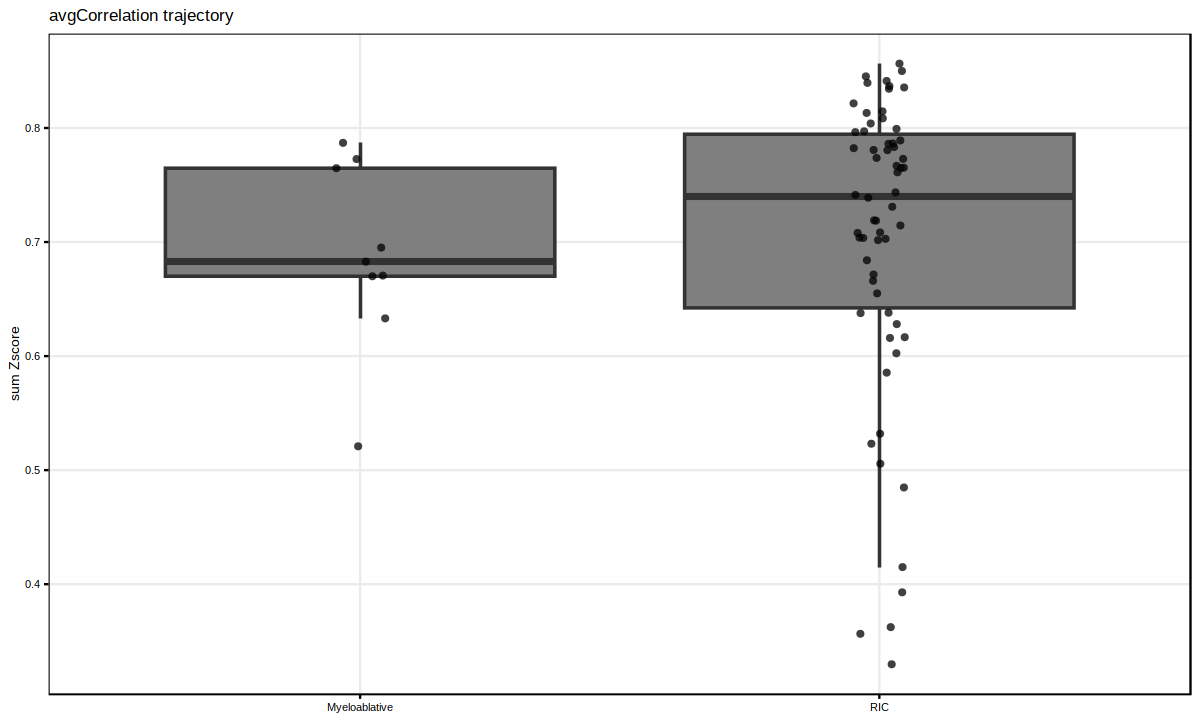

In [ ]:
VAR = "simpson_diversity"


options(repr.plot.width=10, repr.plot.height=6)

mdf_agvhd_t %>% 
    filter(timepoint %in% c("HD","E")) %>%

    # ggplot(aes(x=timepoint, y= !!sym(VAR) , fill =  !is.na(date_agvhd))) +
    # ggplot(aes(x=hct_source, y= !!sym(VAR) , fill = hct_source )) +
    ggplot(aes(x=conditioning_regimen, y= !!sym(VAR) , fill = conditioning_regimen )) +


    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_print()+
    labs(title = gsub("_"," ",VAR), y = "sum Zscore", x = "Timepoint", fill = "Future\nGVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "right",
        legend.text = element_text(size = 6))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))
